
# Clasificación de Carros por Rango de Precio

Este notebook implementa un sistema de clasificación de imágenes usando **Transfer Learning** con EfficientNet.

Objetivo:
- Clasificar carros en:
  - Económico
  - Gama media
  - Lujo

También incluye:
- Evaluación del modelo
- Matriz de confusión
- Predicciones
- Grad-CAM para interpretabilidad



# 1. Instalación de dependencias

Ejecuta esta celda solo si estás trabajando por primera vez.


In [50]:
!pip install torch torchvision torchaudio --quiet
!pip install scikit-learn matplotlib seaborn pandas pillow --quiet
!pip install grad-cam --quiet
!pip install kagglehub --quiet
!pip install gradio --quiet


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# 0. Descarga del Dataset de Kaggle

Descargamos el **Stanford Car Dataset** organizado por clases de Kaggle.

Requiere tener configurado tu API key de Kaggle (`~/.kaggle/kaggle.json`).
Si aún no lo tienes, descárgalo desde [kaggle.com/settings → API](https://www.kaggle.com/settings) y colócalo en esa ruta.

In [51]:
import kagglehub
import os

# Download Stanford Car Dataset by classes folder
path = kagglehub.dataset_download("jutrera/stanford-car-dataset-by-classes-folder")
print("Dataset descargado en:", path)

# Show top-level structure
for root, dirs, files in os.walk(path):
    level = root.replace(path, "").count(os.sep)
    if level > 2:
        break
    indent = "  " * level
    print(f"{indent}{os.path.basename(root)}/")
    if level == 2:
        dirs.clear()

Dataset descargado en: C:\Users\Juan Jose Montoya\.cache\kagglehub\datasets\jutrera\stanford-car-dataset-by-classes-folder\versions\2
2/
  car_data/
    car_data/


# 0.5 Organización del Dataset por Rango de Precio

El dataset de Stanford Cars tiene **196 clases** (modelos de auto).
Esta celda las reorganiza en 3 categorías según el precio del vehículo:

| Categoría | Marcas incluidas |
|-----------|-----------------|
| **Lujo** | Aston Martin, Bentley, Bugatti, Ferrari, Lamborghini, Rolls-Royce, McLaren, Spyker, Maybach + modelos especiales |
| **Gama media** | BMW, Audi, Mercedes-Benz, Cadillac, Acura, Infiniti, Jaguar, Land Rover, Porsche, Tesla, etc. |
| **Económico** | Toyota, Honda, Ford, Chevrolet, Hyundai, Nissan, VW, y demás |

El resultado se copia a `dataset/train/` y `dataset/test/` con la estructura que espera `ImageFolder`.

In [52]:
import shutil
from pathlib import Path

# Mapping rules: checked in order, first match wins
LUXURY_MODELS = [
    "Dodge Viper",
    "Chevrolet Corvette ZR1",
    "Chevrolet Corvette Ron Fellows",
    "Ford GT",
    "BMW M5",
    "BMW M6",
]
LUXURY_BRANDS = [
    "Aston Martin", "Bentley", "Bugatti", "Ferrari",
    "Lamborghini", "Rolls-Royce", "McLaren", "Spyker", "Maybach",
]
MID_RANGE_MODELS = [
    "Chevrolet Corvette", "Chevrolet Camaro", "Chevrolet TrailBlazer SS",
    "Chevrolet Tahoe Hybrid", "Dodge Challenger", "Dodge Charger",
    "Ford Mustang", "GMC Yukon", "Chrysler 300",
    "HUMMER", "Buick Enclave", "Buick Regal",
]
MID_RANGE_BRANDS = [
    "BMW", "Audi", "Mercedes-Benz", "Cadillac", "Infiniti",
    "Jaguar", "Land Rover", "Lincoln", "Volvo",
    "Tesla", "Porsche", "Fisker", "Acura",
]

def get_price_category(class_name: str) -> str:
    for model in LUXURY_MODELS:
        if class_name.startswith(model):
            return "lujo"
    for brand in LUXURY_BRANDS:
        if class_name.startswith(brand):
            return "lujo"
    for model in MID_RANGE_MODELS:
        if class_name.startswith(model):
            return "gama_media"
    for brand in MID_RANGE_BRANDS:
        if class_name.startswith(brand):
            return "gama_media"
    return "economico"

# Find train/test directories inside the downloaded dataset
dataset_root = Path(path)
found_splits = {}
for split in ("train", "test"):
    matches = [p for p in dataset_root.rglob(split) if p.is_dir()]
    if matches:
        found_splits[split] = matches[0]
        print(f"Encontrado {split}: {matches[0]}")
    else:
        print(f"AVISO: directorio '{split}' no encontrado")

# Copy images into dataset/train and dataset/test organized by price category
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp"}

for split, source_dir in found_splits.items():
    dest_dir = Path(f"dataset/{split}")
    for cat in ("economico", "gama_media", "lujo"):
        (dest_dir / cat).mkdir(parents=True, exist_ok=True)

    cat_counts = {"economico": 0, "gama_media": 0, "lujo": 0}

    for class_folder in sorted(source_dir.iterdir()):
        if not class_folder.is_dir():
            continue
        category = get_price_category(class_folder.name)
        for img_file in class_folder.iterdir():
            if img_file.suffix.lower() in IMAGE_EXTENSIONS:
                # Prefix with class name to avoid filename collisions between classes
                dest_name = f"{class_folder.name}_{img_file.name}"
                shutil.copy2(img_file, dest_dir / category / dest_name)
                cat_counts[category] += 1

    for cat, count in cat_counts.items():
        print(f"  {split}/{cat}: {count} imágenes")

print("\nDataset reorganizado correctamente.")

Encontrado train: C:\Users\Juan Jose Montoya\.cache\kagglehub\datasets\jutrera\stanford-car-dataset-by-classes-folder\versions\2\car_data\car_data\train
Encontrado test: C:\Users\Juan Jose Montoya\.cache\kagglehub\datasets\jutrera\stanford-car-dataset-by-classes-folder\versions\2\car_data\car_data\test
  train/economico: 4111 imágenes
  train/gama_media: 2748 imágenes
  train/lujo: 1285 imágenes
  test/economico: 4063 imágenes
  test/gama_media: 2710 imágenes
  test/lujo: 1268 imágenes

Dataset reorganizado correctamente.



# 2. Importación de librerías

Aquí importamos todas las librerías necesarias:
- PyTorch
- torchvision
- métricas
- visualización
- Grad-CAM


In [53]:

import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)


Device: cpu



# 3. Configuración del proyecto

Aquí definimos:
- Tamaño de batch
- Número de épocas
- Learning rate
- Rutas del dataset


In [54]:
BATCH_SIZE    = 64        # más imágenes por paso → menos pasos por época
IMAGE_SIZE    = 224
EPOCHS        = 5         # con transfer learning 5 épocas son suficientes
LEARNING_RATE = 0.0001
EARLY_STOP_PATIENCE = 2   # detiene si val_acc no mejora N épocas seguidas

TRAIN_DIR = "dataset/train"
TEST_DIR  = "dataset/test"

MODEL_SAVE_PATH = "car_classifier.pth"


# 4. Transformaciones de imágenes

Las imágenes se normalizan y aumentan artificialmente con:
- Rotaciones
- Flip horizontal
- Cambios leves de color

Esto ayuda a evitar overfitting.


In [55]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

test_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


# 5. Cargar dataset

La estructura del dataset debe verse así:

```text
dataset/
│
├── train/
│   ├── economico/
│   ├── gama_media/
│   └── lujo/
│
└── test/
    ├── economico/
    ├── gama_media/
    └── lujo/
```


In [56]:
train_dataset = datasets.ImageFolder(TRAIN_DIR, transform=train_transforms)
test_dataset  = datasets.ImageFolder(TEST_DIR,  transform=test_transforms)

# Distribución natural — el sampler ponderado sesgaba demasiado hacia lujo
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    pin_memory=(device.type == "cuda"),
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    pin_memory=(device.type == "cuda"),
)

# Guardar conteos para referencia en otras celdas
class_counts = [
    sum(1 for _, lbl in train_dataset.samples if lbl == i)
    for i in range(len(train_dataset.classes))
]

print("Imágenes por clase (train):")
for cls, cnt in zip(train_dataset.classes, class_counts):
    print(f"  {cls}: {cnt}")
print(f"\nTrain: {len(train_dataset)}  |  Test: {len(test_dataset)}")

Imágenes por clase (train):
  economico: 4111
  gama_media: 2748
  lujo: 1285

Train: 8144  |  Test: 8041



# 6. Visualización del dataset

Mostramos algunas imágenes aleatorias del dataset.


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0665298..1.6813945].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8610327..1.5593902].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.4482791].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0494049..2.64].


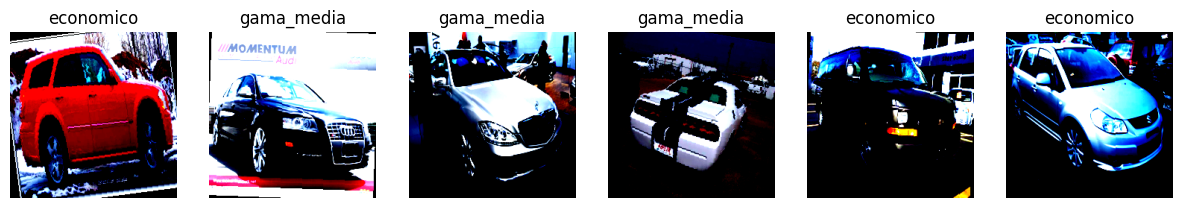

In [57]:

def show_images(dataset, n=6):

    fig, axes = plt.subplots(1, n, figsize=(15,5))

    for i in range(n):

        img, label = dataset[random.randint(0, len(dataset)-1)]

        img = img.permute(1,2,0)

        axes[i].imshow(img)
        axes[i].set_title(dataset.classes[label])
        axes[i].axis("off")

    plt.show()

show_images(train_dataset)



# 7. Modelo preentrenado

Usaremos EfficientNet-B0.

El modelo fue entrenado originalmente en ImageNet.
Nosotros solo cambiamos la capa final para clasificar 3 categorías.


In [58]:
model = models.efficientnet_b0(pretrained=True)

# Congelar todos los bloques de features
for param in model.features.parameters():
    param.requires_grad = False

# Descongelar los últimos 2 bloques para fine-tuning
# (aprende features visuales específicas de carros caros)
for param in model.features[-2:].parameters():
    param.requires_grad = True

# Reemplazar clasificador final
in_features = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(0.3),
    nn.Linear(in_features, 3)
)

model = model.to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Parámetros entrenables: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")

C:\Users\Juan Jose Montoya\AppData\Roaming\Python\Python313\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\Juan Jose Montoya\AppData\Roaming\Python\Python313\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Parámetros entrenables: 1,133,235 / 4,011,391 (28.3%)



# 8. Función de pérdida y optimizador

Usamos:
- CrossEntropyLoss
- Adam optimizer


In [ ]:
# Pesos inversamente proporcionales al tamaño de cada clase
# economico:4111  gama_media:2748  lujo:1285
# -> errores en lujo se penalizan 3.2x más que en economico
class_weights = torch.tensor([1.0, 4111/2748, 4111/1285]).to(device)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1, weight=class_weights)

# LR diferencial: capas preentrenadas descongeladas aprenden más despacio
optimizer = optim.Adam([
    {"params": model.features[-2:].parameters(), "lr": LEARNING_RATE * 0.1},
    {"params": model.classifier.parameters(),    "lr": LEARNING_RATE},
])


# 9. Entrenamiento

Aquí entrenamos el modelo.


In [60]:
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", patience=1, factor=0.5
)

train_losses   = []
val_accuracies = []
best_val_acc   = 0.0
patience_count = 0

for epoch in range(EPOCHS):

    # ── Entrenamiento ──────────────────────────────────────────────────
    model.train()
    running_loss = 0.0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(images), labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)

    # ── Validación ─────────────────────────────────────────────────────
    model.eval()
    correct = total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            _, preds = torch.max(model(images), 1)
            correct += (preds == labels).sum().item()
            total   += labels.size(0)

    val_acc = correct / total
    val_accuracies.append(val_acc)

    prev_lr = optimizer.param_groups[0]["lr"]
    scheduler.step(epoch_loss)
    new_lr  = optimizer.param_groups[0]["lr"]
    lr_msg  = f"  → LR reducido a {new_lr:.2e}" if new_lr < prev_lr else ""

    print(f"Epoch [{epoch+1}/{EPOCHS}]  Loss: {epoch_loss:.4f}  |  Val Acc: {val_acc:.4f}{lr_msg}")

    # ── Guardar mejor modelo ────────────────────────────────────────────
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), MODEL_SAVE_PATH)
        print(f"  ✓ Modelo guardado (mejor val acc: {best_val_acc:.4f})")
        patience_count = 0
    else:
        patience_count += 1
        if patience_count >= EARLY_STOP_PATIENCE:
            print(f"\nEarly stopping en epoch {epoch+1} (sin mejora en {EARLY_STOP_PATIENCE} épocas)")
            break

print(f"\nEntrenamiento completado. Mejor val acc: {best_val_acc:.4f}")

Epoch [1/5]  Loss: 1.0249  |  Val Acc: 0.5382
  ✓ Modelo guardado (mejor val acc: 0.5382)
Epoch [2/5]  Loss: 0.9561  |  Val Acc: 0.5824
  ✓ Modelo guardado (mejor val acc: 0.5824)
Epoch [3/5]  Loss: 0.9194  |  Val Acc: 0.6124
  ✓ Modelo guardado (mejor val acc: 0.6124)
Epoch [4/5]  Loss: 0.8922  |  Val Acc: 0.6329
  ✓ Modelo guardado (mejor val acc: 0.6329)
Epoch [5/5]  Loss: 0.8707  |  Val Acc: 0.6415
  ✓ Modelo guardado (mejor val acc: 0.6415)

Entrenamiento completado. Mejor val acc: 0.6415



# 10. Guardar modelo

Guardamos el modelo entrenado.


In [61]:
# El mejor modelo ya se guardó automáticamente durante el entrenamiento.
# Esta celda lo carga de vuelta para asegurarse de usar los mejores pesos.
model.load_state_dict(torch.load(MODEL_SAVE_PATH, map_location=device))
print(f"Modelo cargado desde '{MODEL_SAVE_PATH}'")

Modelo cargado desde 'car_classifier.pth'



# 11. Curva de entrenamiento

Visualizamos la pérdida durante el entrenamiento.


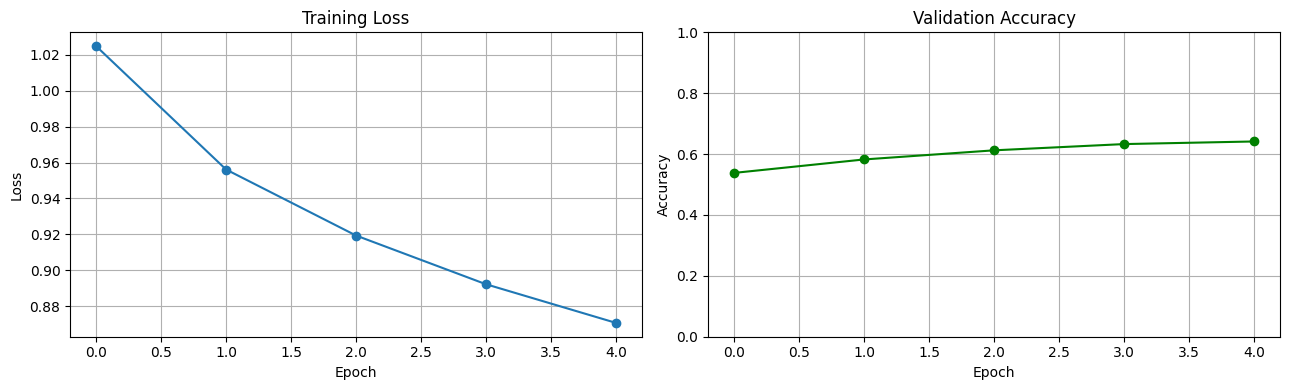

In [62]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(train_losses, marker="o")
ax1.set_title("Training Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.grid(True)

ax2.plot(val_accuracies, marker="o", color="green")
ax2.set_title("Validation Accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.set_ylim(0, 1)
ax2.grid(True)

plt.tight_layout()
plt.show()


# 12. Evaluación del modelo

Calculamos:
- Accuracy
- F1-score


In [63]:

model.eval()

all_preds = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

accuracy = accuracy_score(all_labels, all_preds)

f1 = f1_score(
    all_labels,
    all_preds,
    average="macro"
)

print("Accuracy:", accuracy)
print("Macro F1:", f1)


Accuracy: 0.6414625046635991
Macro F1: 0.568013178018626



# 13. Reporte de clasificación

Mostramos precisión, recall y F1-score por clase.


In [64]:

print(classification_report(
    all_labels,
    all_preds,
    target_names=train_dataset.classes
))


              precision    recall  f1-score   support

   economico       0.69      0.84      0.76      4063
  gama_media       0.53      0.50      0.51      2710
        lujo       0.71      0.31      0.43      1268

    accuracy                           0.64      8041
   macro avg       0.64      0.55      0.57      8041
weighted avg       0.64      0.64      0.62      8041




# 14. Matriz de confusión

Permite visualizar los errores del modelo.


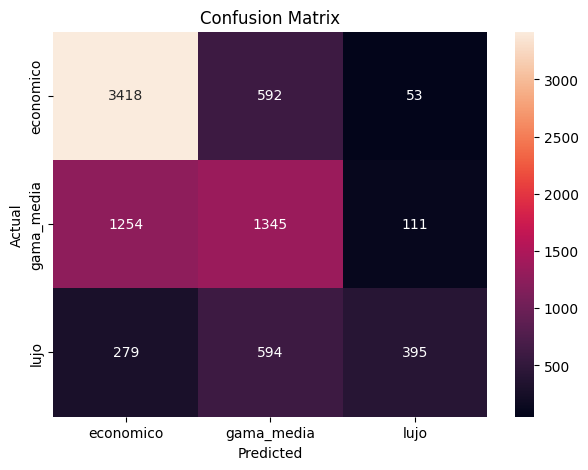

In [65]:

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(7,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=train_dataset.classes,
    yticklabels=train_dataset.classes
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()



# 15. Predicciones aleatorias

Mostramos imágenes y predicciones del modelo.


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0836544..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.1007793..2.64].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0836544..2.6051416].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.5877128].


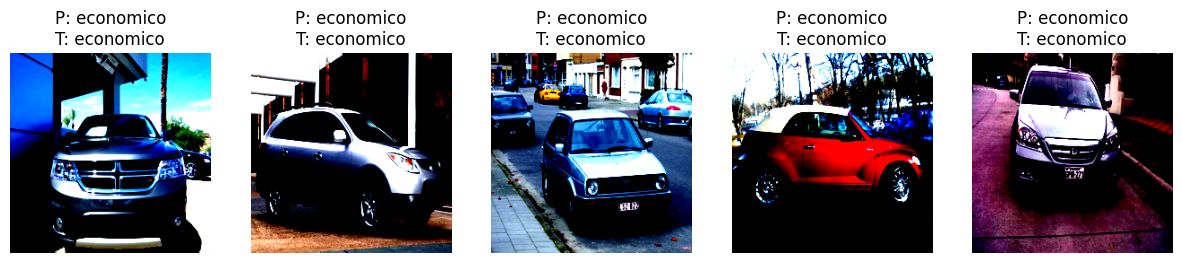

In [66]:

def predict_random_images(dataset, model, n=5):

    model.eval()

    fig, axes = plt.subplots(1, n, figsize=(15,5))

    for i in range(n):

        idx = random.randint(0, len(dataset)-1)

        image, label = dataset[idx]

        input_tensor = image.unsqueeze(0).to(device)

        with torch.no_grad():

            output = model(input_tensor)

            pred = torch.argmax(output, 1).item()

        img = image.permute(1,2,0)

        axes[i].imshow(img)

        axes[i].set_title(
            f"P: {dataset.classes[pred]}\nT: {dataset.classes[label]}"
        )

        axes[i].axis("off")

    plt.show()

predict_random_images(test_dataset, model)



# 16. Grad-CAM

Grad-CAM permite visualizar qué partes de la imagen utilizó el modelo para tomar la decisión.

Esto es importante para interpretabilidad.


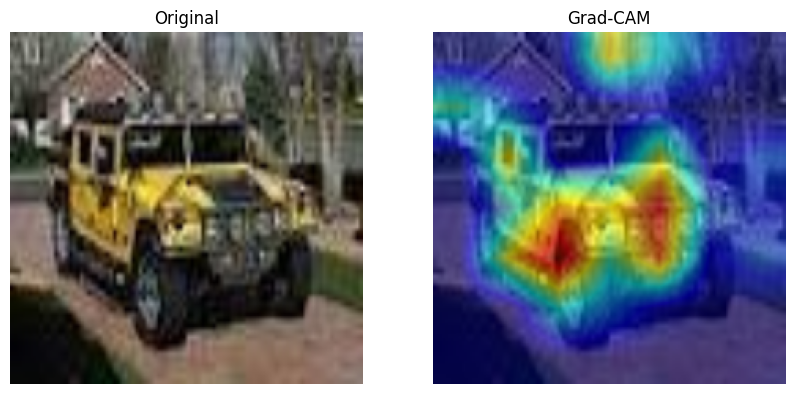

In [67]:
# features[-1] ya tiene gradientes activos (descongelado en sección 7)
target_layer = model.features[-1]

cam = GradCAM(model=model, target_layers=[target_layer])

image, label = test_dataset[0]
input_tensor = image.unsqueeze(0).to(device)
targets      = [ClassifierOutputTarget(label)]

grayscale_cam = cam(input_tensor=input_tensor, targets=targets)[0]

# Desnormalizar para visualización correcta
mean    = np.array([0.485, 0.456, 0.406])
std     = np.array([0.229, 0.224, 0.225])
rgb_img = image.permute(1, 2, 0).numpy()
rgb_img = np.clip(rgb_img * std + mean, 0, 1).astype(np.float32)

visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
ax1.imshow(rgb_img);       ax1.set_title("Original");  ax1.axis("off")
ax2.imshow(visualization); ax2.set_title("Grad-CAM"); ax2.axis("off")
plt.show()


# 17. Predicción de imágenes externas

Puedes probar imágenes nuevas.


In [68]:

def predict_image(image_path):

    model.eval()

    image = Image.open(image_path).convert("RGB")

    transform = transforms.Compose([
        transforms.Resize((224,224)),
        transforms.ToTensor()
    ])

    image_tensor = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():

        output = model(image_tensor)

        pred = torch.argmax(output,1).item()

    plt.imshow(image)

    plt.title(
        f"Prediction: {train_dataset.classes[pred]}"
    )

    plt.axis("off")

    plt.show()

# Ejemplo:
# predict_image("mi_carro.jpg")


# 18. Interfaz Interactiva — Clasifica tu propio carro

Sube cualquier foto de un carro y el modelo te dirá:
- A qué categoría pertenece (Económico / Gama Media / Lujo)
- El rango de precio estimado
- El porcentaje de confianza de cada clase

> Ejecuta la celda y abre el link local que aparece (`http://127.0.0.1:7860`).

In [ ]:
import gradio as gr
import torch
import numpy as np
from torchvision import transforms
from PIL import Image as PILImage
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

try:
    model
except NameError:
    from torchvision import models
    import torch.nn as nn
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = models.efficientnet_b0(pretrained=False)
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(nn.Dropout(0.3), nn.Linear(in_features, 3))
    model.load_state_dict(torch.load("car_classifier.pth", map_location=device))
    model = model.to(device)

CLASS_NAMES = ["economico", "gama_media", "lujo"]

PRICE_INFO = {
    "economico": {
        "titulo": "Económico",   "precio": "$8,000 – $25,000 USD",
        "emoji": "🚗", "color": "#2ecc71",
        "descripcion": "Toyota, Honda, Hyundai, Chevrolet, Ford básico y similares.",
    },
    "gama_media": {
        "titulo": "Gama Media",  "precio": "$25,000 – $65,000 USD",
        "emoji": "🚙", "color": "#f39c12",
        "descripcion": "BMW serie 3, Audi A4, Mercedes C-Class, Cadillac y similares.",
    },
    "lujo": {
        "titulo": "Lujo",        "precio": "$65,000+ USD",
        "emoji": "🏎️", "color": "#e74c3c",
        "descripcion": "Ferrari, Lamborghini, Bentley, Rolls-Royce y similares.",
    },
}

infer_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# Corrección de sesgo de clases:
# El modelo fue entrenado con 4111 eco / 2748 gama / 1285 lujo.
# Sin corrección tiende a predecir "economico" aunque la imagen sea de lujo.
# Multiplicamos cada prob por el inverso de su frecuencia de entrenamiento para compensar.
_TRAIN_COUNTS = [4111, 2748, 1285]
_TOTAL        = sum(_TRAIN_COUNTS)
BIAS_CORR     = [_TOTAL / c for c in _TRAIN_COUNTS]   # [1.98, 2.96, 6.34]
# Normalizamos para que la corrección no infle la confianza total
_mean_corr    = sum(BIAS_CORR) / 3
BIAS_CORR     = [c / _mean_corr for c in BIAS_CORR]   # ~ [0.54, 0.81, 1.74]

PLACEHOLDER_HTML = """
<div style="color:#556677;text-align:center;padding:60px 20px;font-family:'Segoe UI',sans-serif;">
    <p style="font-size:3.5em;margin:0;">🏎️</p>
    <p style="font-size:1.1em;margin-top:12px;">Sube una foto para ver el resultado aquí</p>
</div>"""

def compute_gradcam(tensor, pred_idx):
    target_layer = model.features[-1]
    for param in target_layer.parameters():
        param.requires_grad_(True)
    cam           = GradCAM(model=model, target_layers=[target_layer])
    grayscale_cam = cam(input_tensor=tensor,
                        targets=[ClassifierOutputTarget(pred_idx)])[0]
    return grayscale_cam

def classify_car(image):
    if image is None:
        return PLACEHOLDER_HTML, None

    model.eval()
    tensor = infer_transform(image).unsqueeze(0).to(device)

    # ── Predicción ────────────────────────────────────────────────────
    with torch.no_grad():
        raw_probs = torch.softmax(model(tensor), dim=1)[0].cpu().tolist()

    # Corrección de sesgo: el modelo ve mucho más economico en train
    corrected = [p * bc for p, bc in zip(raw_probs, BIAS_CORR)]
    total_c   = sum(corrected)
    probs     = [c / total_c for c in corrected]

    pred_idx   = probs.index(max(probs))
    pred_class = CLASS_NAMES[pred_idx]
    info       = PRICE_INFO[pred_class]
    confidence = probs[pred_idx] * 100
    p_eco, p_mid, p_lux = probs[0]*100, probs[1]*100, probs[2]*100

    # ── Grad-CAM ──────────────────────────────────────────────────────
    grayscale_cam = compute_gradcam(tensor, pred_idx)
    rgb_img       = np.array(image.resize((224, 224))).astype(np.float32) / 255.0
    visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)
    gradcam_pil   = PILImage.fromarray(visualization)

    # ── HTML resultado ────────────────────────────────────────────────
    def bar(label, emoji, pct, color, winner):
        bold = "font-weight:700;font-size:1.05em;" if winner else "opacity:0.75;"
        return f"""
        <div style="margin-bottom:14px;">
          <div style="display:flex;justify-content:space-between;margin-bottom:5px;{bold}">
            <span style="color:{color};">{emoji} {label}</span>
            <span style="color:{color};">{pct:.1f}%</span>
          </div>
          <div style="background:rgba(255,255,255,0.08);border-radius:10px;height:10px;overflow:hidden;">
            <div style="background:{color};width:{pct:.1f}%;height:100%;border-radius:10px;
                        box-shadow:0 0 8px {color}99;"></div>
          </div>
        </div>"""

    bars = (bar("Económico",  "🟢", p_eco, "#2ecc71", pred_class=="economico") +
            bar("Gama Media", "🟡", p_mid, "#f39c12", pred_class=="gama_media") +
            bar("Lujo",       "🔴", p_lux, "#e74c3c", pred_class=="lujo"))

    html = f"""
    <div style="font-family:'Segoe UI',sans-serif;color:white;padding:8px;">

      <!-- Tarjeta principal -->
      <div style="text-align:center;margin-bottom:18px;
                  background:linear-gradient(135deg,{info['color']}25,{info['color']}10);
                  border:2px solid {info['color']}77;border-radius:20px;padding:22px 16px;">
        <div style="font-size:3.5em;line-height:1;">{info['emoji']}</div>
        <h2 style="color:{info['color']};margin:8px 0 0 0;font-size:1.9em;letter-spacing:1px;">
          {info['titulo']}
        </h2>
        <div style="margin-top:12px;display:inline-block;
                    background:{info['color']}33;border-radius:30px;padding:8px 20px;
                    border:1px solid {info['color']}55;">
          <span style="color:{info['color']};font-size:1.2em;font-weight:700;">
            💰 {info['precio']}
          </span>
        </div>
        <p style="color:#aabbcc;margin:12px 0 4px 0;font-size:0.93em;">{info['descripcion']}</p>
        <p style="color:#667788;font-size:0.86em;margin:0;">
          Confianza: <strong style="color:{info['color']};">{confidence:.1f}%</strong>
        </p>
      </div>

      <!-- Barras de confianza -->
      <div style="background:rgba(255,255,255,0.04);border-radius:16px;padding:16px 18px;
                  border:1px solid rgba(255,255,255,0.09);margin-bottom:14px;">
        <p style="color:#667788;margin:0 0 12px 0;font-size:0.8em;
                  text-transform:uppercase;letter-spacing:2px;font-weight:600;">
          📊 Distribución de confianza
        </p>
        {bars}
      </div>

      <!-- Explicación Grad-CAM -->
      <div style="background:rgba(255,255,255,0.04);border-radius:16px;padding:14px 18px;
                  border:1px solid rgba(255,255,255,0.09);">
        <p style="color:#667788;margin:0 0 8px 0;font-size:0.8em;
                  text-transform:uppercase;letter-spacing:2px;font-weight:600;">
          🔍 En qué se fijó el modelo
        </p>
        <p style="color:#99aabb;font-size:0.88em;margin:0;line-height:1.5;">
          El mapa de calor de abajo muestra las zonas que más influyeron en la decisión.
          <span style="color:#ff6b6b;">Rojo/naranja</span> = mucho peso ·
          <span style="color:#4ecdc4;">Azul/verde</span> = poco peso
        </p>
      </div>
    </div>"""

    return html, gradcam_pil

CSS = """
.gradio-container {
    background: linear-gradient(135deg,#0d0d0d 0%,#1a1a2e 55%,#16213e 100%) !important;
}
#classify-btn {
    background: linear-gradient(90deg,#e94560,#f5a623) !important;
    border: none !important; border-radius: 30px !important;
    font-size: 1.1em !important; font-weight: 700 !important;
    color: white !important;
    box-shadow: 0 4px 18px rgba(233,69,96,0.45) !important;
}
"""

with gr.Blocks() as demo:

    gr.HTML("""
    <div style="text-align:center;padding:26px 0 4px 0;font-family:'Segoe UI',sans-serif;">
      <h1 style="margin:0;font-size:2.5em;font-weight:900;letter-spacing:2px;
                 background:linear-gradient(90deg,#e94560,#f5a623,#4fc3f7);
                 -webkit-background-clip:text;-webkit-text-fill-color:transparent;
                 background-clip:text;">
        🚗 Clasificador de Carros por Precio
      </h1>
      <p style="color:#667788;font-size:1em;margin-top:8px;">
        Sube una foto · El modelo estima el rango de precio y muestra en qué se basó
      </p>
    </div>""")

    with gr.Row(equal_height=False):

        with gr.Column(scale=1):
            image_input  = gr.Image(type="pil", label="📷 Foto del carro")
            classify_btn = gr.Button("✨  Clasificar carro",
                                     elem_id="classify-btn", size="lg")

        with gr.Column(scale=1):
            result_output  = gr.HTML(value=PLACEHOLDER_HTML, label="Resultado")
            gradcam_output = gr.Image(
                type="pil",
                label="🔍 Mapa de atención (Grad-CAM) — zonas rojas = más peso en la decisión",
            )

    classify_btn.click(fn=classify_car,
                       inputs=image_input,
                       outputs=[result_output, gradcam_output])
    image_input.change(fn=classify_car,
                       inputs=image_input,
                       outputs=[result_output, gradcam_output])

demo.launch(css=CSS, theme=gr.themes.Base(), share=False)